# 02 - Feature Engineering Pipeline (RIE BNP Paribas)

**Objectif :** Transformer les données brutes (`data/raw/`) en un jeu de features
propre, reproductible et directement exploitable par les notebooks de modélisation.

Ce notebook constitue la **source de vérité du feature engineering**. Toutes les
décisions de transformation sont documentées en ligne.

### Sections
0. Setup & chargement  
1. Nettoyage & déduplication  
2. Features calendaires  
3. Jours fériés algériens & Ramadan  
4. Features météo  
5. Features effectifs  
6. Features menu (via `menu_cleaning.extract_menu_features`)  
7. Features de lag & fenêtres glissantes  
8. Résumé de la matrice finale  
9. Sauvegarde → `data/processed/`

> **Convention :** Toutes les transformations sont d'abord appliquées sur Train,
> puis répliquées à l'identique sur Test — **sans aucune fuite d'information** entre les deux.

## 0. Setup & Chargement

In [1]:
import sys
import json
import warnings
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── paths ──────────────────────────────────────────────────────────────────
REPO_ROOT  = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR    = REPO_ROOT / 'data' / 'raw'
OUT_DIR    = REPO_ROOT / 'data' / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── import menu cleaning module ───────────────────────────────────────────
import src.menu_optimization.menu_cleaning as menu_cleaning
importlib.reload(menu_cleaning)
from src.menu_optimization.menu_cleaning import extract_menu_features

# ── load raw data ─────────────────────────────────────────────────────────
train_raw = pd.read_csv(RAW_DIR / 'train.csv', parse_dates=['Date'])
test_raw  = pd.read_csv(RAW_DIR / 'test.csv',  parse_dates=['Date'])

print(f"Train brut : {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"Test brut  : {test_raw.shape}  | {test_raw.Date.min().date()} → {test_raw.Date.max().date()}")
print()
print(train_raw.dtypes)

Train brut : (410, 21) | 2022-05-04 → 2023-12-31
Test brut  : (229, 20)  | 2024-01-02 → 2024-12-31

Date                                  datetime64[us]
employees_count                                int64
office_present                                 int64
office_departments                             int64
entrées                                          str
plat pricipal_1                                  str
plat principal_2                                 str
temperature                                  float64
temperature ressentie                        float64
precipitation (mm)                           float64
type precipitation                               str
vitesse soulevement du vent (km/h)           float64
vitesse du vent(km/h)                        float64
couverture nuageuse (%)                      float64
conditions                                       str
year                                           int64
month                                          int64

## 1. Nettoyage & Déduplication

### 1.1 Suppression de l'outlier Ramadan
Le **23 mars 2023** (1er jour du Ramadan 2023) enregistre `employees_count = 1` pour
`office_present = 526`. Il s'agit d'une fermeture exceptionnelle ou d'un défaut de
saisie. Conserver cette ligne biaiserait fortement les modèles.

### 1.2 Déduplication par Date
L'EDA a montré que **20 lignes partagent la même date** avec des descriptions de menu
différentes mais des valeurs numériques identiques (effectifs, météo).

**Stratégie d'agrégation :**
- Colonnes numériques (effectifs, météo, calendrier) → `first`
- Colonnes texte menu brut → `first` (la version la plus complète)
- Colonnes features menu binaires → `max` (l'union des variantes du jour)
- `employees_count` → `mean` (moyenne si vraiment différent — cas rare)

In [2]:
RAMADAN_OUTLIER = pd.Timestamp('2023-03-23')

def clean_and_deduplicate(df: pd.DataFrame, has_target: bool) -> pd.DataFrame:
    """
    1. Supprime l'outlier Ramadan du train.
    2. Extrait les features de menu sur les lignes brutes.
    3. Déduplique par Date.
    """
    out = df.copy()

    # ── 1. Ramadan outlier (train seulement) ─────────────────────────────
    if has_target and RAMADAN_OUTLIER in out['Date'].values:
        out = out[out['Date'] != RAMADAN_OUTLIER].copy()
        print(f"  ✓ Outlier {RAMADAN_OUTLIER.date()} retiré → {len(out)} lignes restantes")

    # ── 2. Extraction des features menu (avant dédup, sur lignes brutes) ──
    menu_feats = extract_menu_features(out)
    out = pd.concat([out, menu_feats], axis=1)

    # ── 3. Déduplication ─────────────────────────────────────────────────
    menu_cols = [c for c in out.columns
                 if c.startswith('menu_') or c.startswith('entree_')
                 or c in {'n_entree_choices', 'has_2nd_plat', 'is_menu_chef'}]

    raw_text_cols = ['entrées', 'plat pricipal_1', 'plat principal_2',
                     'conditions', 'type precipitation']

    agg = {}
    for col in out.columns:
        if col == 'Date':
            continue
        if col in menu_cols:
            agg[col] = 'max'          # union des variantes du jour
        elif col == 'employees_count' and has_target:
            agg[col] = 'mean'
        elif col in raw_text_cols:
            agg[col] = 'first'
        elif out[col].dtype.kind in 'biufc':
            agg[col] = 'first'
        else:
            agg[col] = 'first'

    daily = (out.groupby('Date', as_index=False)
               .agg(agg)
               .sort_values('Date')
               .reset_index(drop=True))
    return daily


print("── Train ──")
train_daily = clean_and_deduplicate(train_raw, has_target=True)
print(f"  Brut : {len(train_raw)} lignes → Dédupliqué : {len(train_daily)} dates uniques")

print("── Test ──")
test_daily = clean_and_deduplicate(test_raw, has_target=False)
print(f"  Brut : {len(test_raw)} lignes → Dédupliqué : {len(test_daily)} dates uniques")

── Train ──
  ✓ Outlier 2023-03-23 retiré → 409 lignes restantes
  Brut : 410 lignes → Dédupliqué : 399 dates uniques
── Test ──
  Brut : 229 lignes → Dédupliqué : 229 dates uniques


In [3]:
# Vérification : aucun doublon de date dans les frames dédupliquées
assert train_daily['Date'].is_unique, "Doublons résiduels dans train_daily !"
assert test_daily['Date'].is_unique,  "Doublons résiduels dans test_daily !"
print("✓ Aucun doublon de date résiduel.")

✓ Aucun doublon de date résiduel.


## 2. Features Calendaires

Toutes les features temporelles sont recalculées depuis la colonne `Date`
pour neutraliser la discontinuité d'encodage de `dayofweek` identifiée en EDA.

| Feature | Description |
|---|---|
| `dayofweek` | `(dt.dayofweek + 1) % 7` → 0=Dim, 1=Lun, …, 4=Jeu (semaine algérienne) |
| `month` | 1–12 |
| `day` | Jour du mois (1–31) |
| `weekofyear` | Semaine ISO |
| `year` | 2022 / 2023 / 2024 |
| `quarter` | 1–4 |
| `month_sin/cos` | Encodage cyclique du mois |
| `week_sin/cos` | Encodage cyclique de la semaine |
| `dow_sin/cos` | Encodage cyclique du jour de la semaine |

> **Pourquoi l'encodage cyclique ?** Les modèles GBM traitent les features numériques
> comme ordonnées. L'encodage cyclique (sin/cos) garantit que Décembre (12) est bien
> proche de Janvier (1) — contrairement à une valeur entière brute.

In [4]:
DAY_MAP_FR = {
    'Sunday': 'Dimanche', 'Monday': 'Lundi', 'Tuesday': 'Mardi',
    'Wednesday': 'Mercredi', 'Thursday': 'Jeudi',
    'Friday': 'Vendredi', 'Saturday': 'Samedi'
}

def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = out['Date'].dt

    out['dayofweek']   = (dt.dayofweek + 1) % 7   # 0=Dimanche … 4=Jeudi
    out['day_name_fr'] = dt.day_name().map(DAY_MAP_FR)
    out['month']       = dt.month
    out['day']         = dt.day
    out['weekofyear']  = dt.isocalendar().week.astype(int)
    out['year']        = dt.year
    out['quarter']     = dt.quarter

    # Cyclical encodings
    out['month_sin'] = np.sin(2 * np.pi * out['month']      / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month']      / 12)
    out['week_sin']  = np.sin(2 * np.pi * out['weekofyear'] / 52)
    out['week_cos']  = np.cos(2 * np.pi * out['weekofyear'] / 52)
    out['dow_sin']   = np.sin(2 * np.pi * out['dayofweek']  / 5)
    out['dow_cos']   = np.cos(2 * np.pi * out['dayofweek']  / 5)

    return out

train_daily = add_calendar_features(train_daily)
test_daily  = add_calendar_features(test_daily)

print("Features calendaires ajoutées :")
print(train_daily[['Date','dayofweek','day_name_fr','month','weekofyear','year',
                    'month_sin','month_cos','dow_sin','dow_cos']].head(10).to_string(index=False))

Features calendaires ajoutées :
      Date  dayofweek day_name_fr  month  weekofyear  year  month_sin  month_cos   dow_sin   dow_cos
2022-05-04          3    Mercredi      5          18  2022        0.5  -0.866025 -0.587785 -0.809017
2022-05-05          4       Jeudi      5          18  2022        0.5  -0.866025 -0.951057  0.309017
2022-05-08          0    Dimanche      5          18  2022        0.5  -0.866025  0.000000  1.000000
2022-05-09          1       Lundi      5          19  2022        0.5  -0.866025  0.951057  0.309017
2022-05-10          2       Mardi      5          19  2022        0.5  -0.866025  0.587785 -0.809017
2022-05-11          3    Mercredi      5          19  2022        0.5  -0.866025 -0.587785 -0.809017
2022-05-12          4       Jeudi      5          19  2022        0.5  -0.866025 -0.951057  0.309017
2022-05-15          0    Dimanche      5          19  2022        0.5  -0.866025  0.000000  1.000000
2022-05-16          1       Lundi      5          20  2022 

## 3. Jours Fériés Algériens & Ramadan

### Jours fériés officiels
Utilisation de la librairie `holidays` (Algeria) pour détecter les jours
fériés légaux (1er Janvier, 1er Mai, 5 Juillet, 1er Novembre, etc.) ainsi que
les fêtes islamiques (Aïd el-Fitr, Aïd el-Adha, Mawlid, etc.).

### Ramadan
Fenêtres empiriques calibrées sur les données du RIE :

| Année | Début | Fin |
|---|---|---|
| 2022 | 02/04/2022 | 01/05/2022 |
| 2023 | 23/03/2023 | 20/04/2023 |
| 2024 | 11/03/2024 | 09/04/2024 |

In [6]:
try:
    import holidays as hol
    HAS_HOLIDAYS = True
except ImportError:
    HAS_HOLIDAYS = False
    print("⚠ Librairie 'holidays' non disponible — is_holiday sera mis à 0.")

RAMADAN_WINDOWS = [
    (pd.Timestamp('2022-04-02'), pd.Timestamp('2022-05-01')),
    (pd.Timestamp('2023-03-23'), pd.Timestamp('2023-04-20')),
    (pd.Timestamp('2024-03-11'), pd.Timestamp('2024-04-09')),
]

def _in_windows(dates: pd.Series, windows) -> pd.Series:
    mask = pd.Series(False, index=dates.index)
    for start, end in windows:
        mask |= dates.between(start, end)
    return mask

def _ramadan_day(date: pd.Timestamp) -> int:
    """Retourne le numéro du jour dans le Ramadan (1-30), 0 si hors Ramadan."""    
    for start, end in RAMADAN_WINDOWS:
        if start <= date <= end:
            return (date - start).days + 1
    return 0

def add_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    years = out['Date'].dt.year.unique().tolist()

    if HAS_HOLIDAYS:
        dz_holidays = {}
        for y in years:
            dz_holidays.update(hol.Algeria(years=y))
        out['is_holiday'] = out['Date'].dt.date.astype(str).map(
            lambda d: int(d in {str(k) for k in dz_holidays.keys()})
        ).fillna(0).astype(int)
        out['is_pre_holiday'] = out['Date'].apply(
            lambda d: int((d + pd.Timedelta(days=1)).date() in dz_holidays)
        ).astype(int)
    else:
        out['is_holiday']     = 0
        out['is_pre_holiday'] = 0

    # Ramadan features
    out['is_ramadan'] = _in_windows(out['Date'], RAMADAN_WINDOWS).astype(int)
    out['ramadan_day'] = out['Date'].apply(_ramadan_day)

    pre_windows  = [(s - pd.Timedelta(days=7), s - pd.Timedelta(days=1)) for s, _ in RAMADAN_WINDOWS]
    post_windows = [(e + pd.Timedelta(days=1), e + pd.Timedelta(days=7)) for _, e in RAMADAN_WINDOWS]
    out['is_pre_ramadan']  = _in_windows(out['Date'], pre_windows).astype(int)
    out['is_post_ramadan'] = _in_windows(out['Date'], post_windows).astype(int)

    return out

train_daily = add_holiday_features(train_daily)
test_daily  = add_holiday_features(test_daily)

holiday_cols = ['is_holiday','is_pre_holiday','is_ramadan','ramadan_day',
                'is_pre_ramadan','is_post_ramadan']
print("Répartition des features de jours fériés / Ramadan (Train) :")
print(train_daily[holiday_cols].sum().to_frame('Jours concernés'))

Répartition des features de jours fériés / Ramadan (Train) :
                 Jours concernés
is_holiday                     1
is_pre_holiday                11
is_ramadan                     0
ramadan_day                    0
is_pre_ramadan                 5
is_post_ramadan                8


## 4. Features Météo

**Rappel EDA §6 :** La corrélation brute température↔ratio est $+0.46$, mais
tombe à $-0.08$ après contrôle par le mois (proxy saisonnier). Pour ne pas
doubler la saisonnalité, on résidualise la température par rapport à la
**moyenne mensuelle du train**.

| Feature | Description |
|---|---|
| `has_rain` | Binaire — précipitations > 0.5 mm |
| `temp_z` | Température standardisée (z-score, fit sur train uniquement) |
| `temp_month_delta` | `temperature - moyenne mensuelle (train)` |

In [7]:
def add_weather_features(df: pd.DataFrame, month_temp_means: pd.Series = None,
                         temp_mean: float = None, temp_std: float = None):
    out = df.copy()

    precip_col = 'precipitation (mm)'
    temp_col   = 'temperature'

    out['has_rain'] = (out[precip_col].fillna(0) > 0.5).astype(int)

    # z-score : fit sur train, apply sur train+test
    if temp_mean is None:
        temp_mean = out[temp_col].mean()
        temp_std  = out[temp_col].std()
    out['temp_z'] = (out[temp_col] - temp_mean) / (temp_std + 1e-9)

    # résidualisation par mois
    if month_temp_means is None:
        month_temp_means = out.groupby('month')[temp_col].mean()
    out['temp_month_delta'] = out[temp_col] - out['month'].map(month_temp_means)

    return out, month_temp_means, temp_mean, temp_std

train_daily, month_temp_means, temp_mean, temp_std = add_weather_features(train_daily)
test_daily, *_ = add_weather_features(test_daily,
                                       month_temp_means=month_temp_means,
                                       temp_mean=temp_mean,
                                       temp_std=temp_std)

print(f"Paramètres météo (fit sur train) :")
print(f"  temp_mean={temp_mean:.2f}°C, temp_std={temp_std:.2f}°C")
print(f"  Moyennes mensuelles :")
print(month_temp_means.round(2))

Paramètres météo (fit sur train) :
  temp_mean=21.55°C, temp_std=5.65°C
  Moyennes mensuelles :
month
1     12.72
2     12.74
3     15.21
4     20.70
5     20.05
6     24.37
7     28.67
8     27.74
9     25.89
10    23.29
11    18.13
12    15.58
Name: temperature, dtype: float64


## 5. Features Effectifs

| Feature | Description |
|---|---|
| `office_present` | Effectif présent sur site ce jour (stable Train/Test) |
| `office_per_dept` | `office_present / office_departments` (ratio d'occupation par département) |

> ⚠️ **Distribution shift sur `office_departments` :** L'EDA a montré un décalage
> majeur entre le train (35–54) et le test (42–124). On conserve le ratio
> `office_per_dept` mais on évite d'utiliser `office_departments` en brut
> comme feature dans les modèles.

In [8]:
def add_headcount_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['office_per_dept'] = (
        out['office_present'] / out['office_departments'].replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)
    return out

train_daily = add_headcount_features(train_daily)
test_daily  = add_headcount_features(test_daily)

print("Distribution de office_present (Train vs Test) :")
print(pd.DataFrame({
    'Train': train_daily['office_present'].describe(),
    'Test' : test_daily['office_present'].describe()
}).round(1))

print("\nDistribution de office_departments (⚠ shift Train/Test) :")
print(pd.DataFrame({
    'Train': train_daily['office_departments'].describe(),
    'Test' : test_daily['office_departments'].describe()
}).round(1))

Distribution de office_present (Train vs Test) :
       Train   Test
count  399.0  229.0
mean   536.7  560.8
std     55.4   54.2
min    270.0  313.0
25%    510.0  538.0
50%    547.0  572.0
75%    575.5  599.0
max    628.0  643.0

Distribution de office_departments (⚠ shift Train/Test) :
       Train   Test
count  399.0  229.0
mean    48.2   89.4
std      2.8   32.1
min     35.0   42.0
25%     47.0   50.0
50%     48.0  110.0
75%     50.0  117.0
max     54.0  124.0


## 6. Features Menu

Les 24 features de menu ont déjà été extraites lors de la phase de nettoyage
(Section 1) via `extract_menu_features()`. On affiche ici leur couverture et
leur corrélation avec le ratio de fréquentation.

Les features menu présentes dans le DataFrame :

In [9]:
menu_feat_cols = [c for c in train_daily.columns
                  if c.startswith('menu_') or c.startswith('entree_')
                  or c in {'n_entree_choices', 'has_2nd_plat', 'is_menu_chef'}]

print(f"Nombre de features menu : {len(menu_feat_cols)}")
print(menu_feat_cols)

Nombre de features menu : 24
['has_2nd_plat', 'is_menu_chef', 'menu_is_traditional', 'menu_is_light', 'menu_poulet', 'menu_boeuf', 'menu_poisson', 'menu_dinde', 'menu_veau', 'menu_sans_viande', 'menu_grille', 'menu_pane_frit', 'menu_sauce_mijote', 'menu_gratin', 'menu_frite', 'menu_riz', 'menu_pates', 'menu_pomme_terre', 'menu_legumes', 'entree_salade', 'entree_soupe', 'entree_sale', 'entree_bourek', 'n_entree_choices']


In [10]:
# Couverture des features menu (train)
train_daily['ratio'] = train_daily['employees_count'] / train_daily['office_present']

coverage = []
for col in menu_feat_cols:
    if col == 'n_entree_choices':
        coverage.append({'Feature': col, 'Jours actifs': '-', 'Taux (%)': '-',
                         'Corr (ratio)': round(train_daily[col].corr(train_daily['ratio']), 3)})
        continue
    cnt = int(train_daily[col].sum())
    pct = train_daily[col].mean() * 100
    corr = train_daily[col].corr(train_daily['ratio'])
    coverage.append({'Feature': col, 'Jours actifs': cnt,
                     'Taux (%)': f"{pct:.1f}", 'Corr (ratio)': round(corr, 3)})

cov_df = pd.DataFrame(coverage).sort_values('Corr (ratio)', ascending=False)
print(cov_df.to_string(index=False))

            Feature Jours actifs Taux (%)  Corr (ratio)
        entree_sale          235     58.9         0.372
       has_2nd_plat          165     41.4         0.355
   n_entree_choices            -        -         0.305
     menu_pane_frit          101     25.3         0.253
         menu_frite           53     13.3         0.227
      menu_is_light           56     14.0         0.207
      entree_salade          332     83.2         0.178
       is_menu_chef           45     11.3         0.144
        menu_grille           96     24.1         0.139
   menu_pomme_terre           92     23.1         0.117
       menu_poisson           34      8.5         0.094
   menu_sans_viande           49     12.3         0.059
           menu_riz           72     18.0         0.046
       entree_soupe          240     60.2         0.045
        menu_poulet          241     60.4         0.020
          menu_veau            4      1.0         0.012
  menu_sauce_mijote          157     39.3       

## 7. Features de Lag & Fenêtres Glissantes

Les lags et les fenêtres glissantes capturent la **dynamique temporelle**
de la fréquentation — les modèles GBM n'ont pas de mémoire intrinsèque.

### Stratégie pour le jeu de test
Les premières lignes de test (Janvier 2024) n'ont pas de passé dans le test.
On complète les valeurs initiales manquantes avec les **dernières valeurs du train**.

| Feature | Fenêtre | Description |
|---|---|---|
| `lag_7` | 7 jours | `employees_count` il y a 7 jours |
| `lag_14` | 14 jours | `employees_count` il y a 14 jours |
| `lag_28` | 28 jours | `employees_count` il y a 28 jours |
| `roll_mean_7` | 7 jours | Moyenne glissante de `employees_count` |
| `roll_mean_14` | 14 jours | Moyenne glissante de `employees_count` |
| `roll_std_7` | 7 jours | Écart-type glissant (signal de volatilité) |
| `roll_max_7` | 7 jours | Maximum glissant |
| `lag_ratio_7` | 7 jours | `ratio` il y a 7 jours |
| `roll_ratio_mean_7` | 7 jours | Moyenne glissante du ratio |

In [11]:
def add_lag_features(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Calcule les features de lag et de fenêtres glissantes.
    Les lags du test sont remplis avec les dernières valeurs du train.
    Aucune fuite : les fenêtres sont calculées en .shift(1) (valeurs passées uniquement).
    """
    train = train_df.copy().sort_values('Date').reset_index(drop=True)
    test  = test_df.copy().sort_values('Date').reset_index(drop=True)

    # Série temporelle complète pour calculer les lags sur le test
    full_series = pd.concat([
        train[['Date', 'employees_count', 'ratio']],
        test[['Date']].assign(employees_count=np.nan, ratio=np.nan)
    ], ignore_index=True).sort_values('Date').reset_index(drop=True)

    # Remplir les valeurs manquantes du test en forward-fill depuis le train
    full_series['employees_count'] = full_series['employees_count'].ffill()
    full_series['ratio']           = full_series['ratio'].ffill()

    for lag in [7, 14, 28]:
        full_series[f'lag_{lag}'] = full_series['employees_count'].shift(lag)

    full_series['roll_mean_7']       = full_series['employees_count'].shift(1).rolling(7, min_periods=1).mean()
    full_series['roll_mean_14']      = full_series['employees_count'].shift(1).rolling(14, min_periods=1).mean()
    full_series['roll_std_7']        = full_series['employees_count'].shift(1).rolling(7, min_periods=2).std()
    full_series['roll_max_7']        = full_series['employees_count'].shift(1).rolling(7, min_periods=1).max()
    full_series['lag_ratio_7']       = full_series['ratio'].shift(7)
    full_series['roll_ratio_mean_7'] = full_series['ratio'].shift(1).rolling(7, min_periods=1).mean()

    lag_cols = ['lag_7','lag_14','lag_28',
                'roll_mean_7','roll_mean_14','roll_std_7','roll_max_7',
                'lag_ratio_7','roll_ratio_mean_7']

    train = train.merge(full_series[['Date'] + lag_cols], on='Date', how='left')
    test  = test.merge(full_series[['Date'] + lag_cols], on='Date', how='left')

    return train, test

train_daily, test_daily = add_lag_features(train_daily, test_daily)

print("Features de lag / rolling (premières lignes train) :")
lag_cols = ['Date','employees_count','lag_7','lag_14','lag_28',
            'roll_mean_7','roll_std_7','roll_max_7','lag_ratio_7']
print(train_daily[lag_cols].head(15).to_string(index=False))

Features de lag / rolling (premières lignes train) :
      Date  employees_count  lag_7  lag_14  lag_28  roll_mean_7  roll_std_7  roll_max_7  lag_ratio_7
2022-05-04            180.0    NaN     NaN     NaN          NaN         NaN         NaN          NaN
2022-05-05            222.0    NaN     NaN     NaN   180.000000         NaN       180.0          NaN
2022-05-08            244.0    NaN     NaN     NaN   201.000000   29.698485       222.0          NaN
2022-05-09            234.0    NaN     NaN     NaN   215.333333   32.516662       244.0          NaN
2022-05-10            242.0    NaN     NaN     NaN   220.000000   28.142495       244.0          NaN
2022-05-11            230.0    NaN     NaN     NaN   224.400000   26.283074       244.0          NaN
2022-05-12            295.0    NaN     NaN     NaN   225.333333   23.619201       244.0          NaN
2022-05-15            280.0  180.0     NaN     NaN   235.285714   34.032897       295.0     0.440098
2022-05-16            250.0  222.0    

In [12]:
# Vérification : pas de NaN dans les lags du test
lag_feat_cols = ['lag_7','lag_14','lag_28',
                 'roll_mean_7','roll_mean_14','roll_std_7','roll_max_7',
                 'lag_ratio_7','roll_ratio_mean_7']

null_test = test_daily[lag_feat_cols].isna().sum()
if null_test.sum() == 0:
    print("✓ Aucun NaN dans les features de lag du test.")
else:
    print("⚠ NaN résiduels dans les features de lag du test :")
    print(null_test[null_test > 0])

✓ Aucun NaN dans les features de lag du test.


## 8. Résumé de la Matrice de Features Finale

Inventaire complet des features produites, avec types, taux de nullité, et
corrélation avec la cible ratio (train uniquement).

In [13]:
# Liste finale des features (hors colonnes brutes et texte)
EXCLUDE_COLS = {'Date', 'day_name_fr', 'dayofweek',  # dayofweek conservé sous forme cyclique
                'entrées', 'plat pricipal_1', 'plat principal_2',
                'conditions', 'type precipitation',
                'employees_count', 'ratio',
                'year'}  # year conservé mais mentionné séparément

feature_cols = [c for c in train_daily.columns if c not in EXCLUDE_COLS]
print(f"Nombre total de features : {len(feature_cols)}\n")

summary_rows = []
for col in feature_cols:
    try:
        corr = float(pd.to_numeric(train_daily[col], errors='coerce').corr(train_daily['ratio']))
    except Exception:
        corr = np.nan
    summary_rows.append({
        'Feature'   : col,
        'Type'      : str(train_daily[col].dtype),
        'Nulls (train)': int(train_daily[col].isna().sum()),
        'Nulls (test)' : int(test_daily[col].isna().sum()) if col in test_daily.columns else -1,
        'Corr (ratio)' : round(corr, 3) if not np.isnan(corr) else np.nan
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.sort_values('Corr (ratio)', key=abs, ascending=False).to_string(index=False))

Nombre total de features : 62

                           Feature    Type  Nulls (train)  Nulls (test)  Corr (ratio)
                 roll_ratio_mean_7 float64              1             0         0.614
                         month_sin float64              0             0        -0.524
             temperature ressentie float64              0             0         0.493
                       temperature float64              0             0         0.490
                            temp_z float64              0             0         0.490
                          week_sin float64              0             0        -0.441
                       lag_ratio_7 float64              7             0         0.405
                       entree_sale   int64              0             0         0.372
                      has_2nd_plat   int64              0             0         0.355
                          week_cos float64              0             0        -0.333
                      r

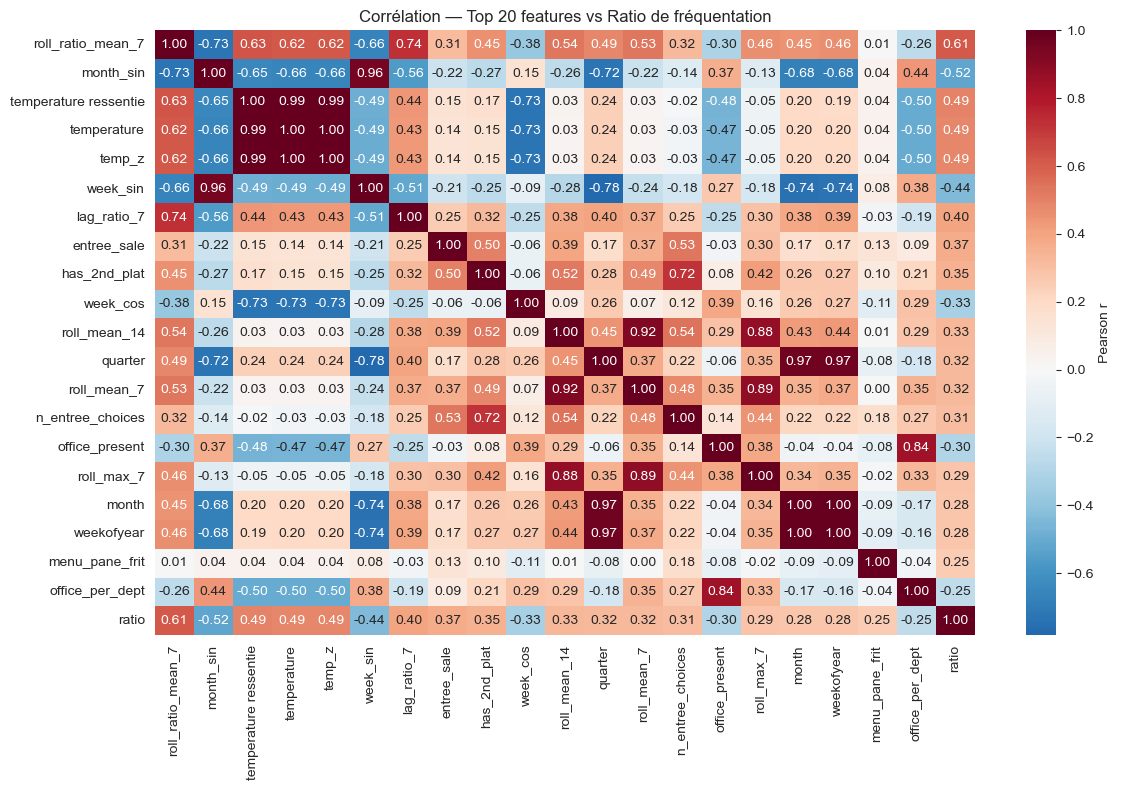

In [14]:
# Heatmap des top-20 features les plus corrélées au ratio
top20 = (summary_df.dropna(subset=['Corr (ratio)'])
                   .reindex(summary_df['Corr (ratio)'].abs().sort_values(ascending=False).index)
                   .head(20)['Feature'].tolist())

corr_vals = train_daily[top20 + ['ratio']].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_vals, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Corrélation — Top 20 features vs Ratio de fréquentation')
plt.tight_layout()
plt.show()

## 9. Sauvegarde → `data/processed/`

Les fichiers produits sont :
- `train_features.parquet` — features + cibles (`employees_count`, `ratio`)
- `test_features.parquet` — features uniquement (pas de cible)
- `feature_columns.json` — liste ordonnée des features pour les notebooks de modélisation

> **Pourquoi Parquet ?** Typage fort, compression, lecture ~10× plus rapide que CSV pour les DataFrames Pandas.

In [15]:
# Colonnes cibles et de référence à conserver dans le fichier train
TARGET_COLS = ['employees_count', 'ratio']
REF_COLS    = ['Date']

# Features finales : exclure texte brut, colonnes redondantes
FINAL_EXCLUDE = {
    'entrées', 'plat pricipal_1', 'plat principal_2',
    'day_name_fr',           # lisible mais inutile pour le modèle
    'precipitation (mm)',    # remplacé par has_rain + raw déjà présent
    'office_departments',    # shift train/test — garder office_per_dept
    'temperature ressentie', # haute colinéarité avec temperature
}

feature_cols_final = [c for c in train_daily.columns
                      if c not in FINAL_EXCLUDE
                      and c not in TARGET_COLS
                      and c not in REF_COLS]

print(f"Features finales retenues : {len(feature_cols_final)}")
print(feature_cols_final)

Features finales retenues : 63
['office_present', 'temperature', 'type precipitation', 'vitesse soulevement du vent (km/h)', 'vitesse du vent(km/h)', 'couverture nuageuse (%)', 'conditions', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'is_weekend', 'has_2nd_plat', 'is_menu_chef', 'menu_is_traditional', 'menu_is_light', 'menu_poulet', 'menu_boeuf', 'menu_poisson', 'menu_dinde', 'menu_veau', 'menu_sans_viande', 'menu_grille', 'menu_pane_frit', 'menu_sauce_mijote', 'menu_gratin', 'menu_frite', 'menu_riz', 'menu_pates', 'menu_pomme_terre', 'menu_legumes', 'entree_salade', 'entree_soupe', 'entree_sale', 'entree_bourek', 'n_entree_choices', 'quarter', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'dow_sin', 'dow_cos', 'is_holiday', 'is_pre_holiday', 'is_ramadan', 'ramadan_day', 'is_pre_ramadan', 'is_post_ramadan', 'has_rain', 'temp_z', 'temp_month_delta', 'office_per_dept', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_14', 'roll_std_7', 'roll_max_7', 'lag_ratio_7', 'roll

In [16]:
# ── Sauvegarde train ─────────────────────────────────────────────────────
train_out = train_daily[REF_COLS + feature_cols_final + TARGET_COLS].copy()
train_out.to_parquet(OUT_DIR / 'train_features.parquet', index=False)

# ── Sauvegarde test ──────────────────────────────────────────────────────
test_feat_cols = [c for c in feature_cols_final if c in test_daily.columns]
test_out = test_daily[REF_COLS + test_feat_cols].copy()
test_out.to_parquet(OUT_DIR / 'test_features.parquet', index=False)

# ── feature_columns.json ─────────────────────────────────────────────────
with open(OUT_DIR / 'feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols_final, f, indent=2, ensure_ascii=False)

print(f"✓ train_features.parquet → {train_out.shape}  ({(OUT_DIR/'train_features.parquet').stat().st_size/1024:.1f} KB)")
print(f"✓ test_features.parquet  → {test_out.shape}  ({(OUT_DIR/'test_features.parquet').stat().st_size/1024:.1f} KB)")
print(f"✓ feature_columns.json   → {len(feature_cols_final)} features")

✓ train_features.parquet → (399, 66)  (80.5 KB)
✓ test_features.parquet  → (229, 64)  (51.5 KB)
✓ feature_columns.json   → 63 features


In [17]:
# ── Vérification finale de cohérence ─────────────────────────────────────
train_reload = pd.read_parquet(OUT_DIR / 'train_features.parquet')
test_reload  = pd.read_parquet(OUT_DIR / 'test_features.parquet')

print("── Train rechargé ──")
print(f"  Shape : {train_reload.shape}")
print(f"  Dates : {train_reload.Date.min().date()} → {train_reload.Date.max().date()}")
print(f"  NaN totaux : {train_reload.isna().sum().sum()}")

print("\n── Test rechargé ──")
print(f"  Shape : {test_reload.shape}")
print(f"  Dates : {test_reload.Date.min().date()} → {test_reload.Date.max().date()}")
print(f"  NaN totaux : {test_reload.isna().sum().sum()}")

print("\n✅ Pipeline feature engineering terminé avec succès.")
print(f"   Fichiers disponibles dans : {OUT_DIR}")

── Train rechargé ──
  Shape : (399, 66)
  Dates : 2022-05-04 → 2023-12-31
  NaN totaux : 337

── Test rechargé ──
  Shape : (229, 64)
  Dates : 2024-01-02 → 2024-12-31
  NaN totaux : 154

✅ Pipeline feature engineering terminé avec succès.
   Fichiers disponibles dans : d:\BNP_RIE_Stage\rie-project-skeleton\rie-project\data\processed
